# Análisis Avanzado de Datos — Taller 03

**Autores:** Miguel Ángel Castelblanco García · Luis Gabriel Durán Fernández  
**Fecha:** 2026-05-19

---

## Estructura del taller

| Problema | Tipo | Puntos | Descripción |
|---|---|---|---|
| 1 | Teórico | 20 | Familia exponencial (Bernoulli, Normal, Poisson) |
| 2 | Práctico | 50 | Regresión logística — Heart Disease (UCI) |
| 3 | Práctico | 20 | Comparación de modelos de predicción crediticia |
| 4 | Práctico | 10 | Problema 2 con imputación EM |

### Archivos requeridos en el mismo directorio
- `AAD-taller03.xlsx` — datos de predicción de incumplimiento (Problema 3)
- El dataset Heart Disease se descarga automáticamente desde UCI.
- Las figuras se guardan en `./figures/`


In [43]:
# ============================================================
# CELDA 0 — SETUP DE ENTORNO
# Ejecutar UNA sola vez para garantizar compatibilidad de versiones.
# ============================================================

import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Verificar versión de statsmodels antes de importar
try:
    import statsmodels
    from packaging.version import Version
    if Version(statsmodels.__version__) < Version("0.14.4"):
        print(f"statsmodels {statsmodels.__version__} es incompatible con scipy>=1.14. Actualizando...")
        pip_install("statsmodels>=0.14.4")
        print("✓ statsmodels actualizado. REINICIAR el kernel y volver a ejecutar.")
    else:
        print(f"✓ statsmodels {statsmodels.__version__} — compatible.")
except ImportError:
    print("statsmodels no encontrado. Instalando...")
    pip_install("statsmodels>=0.14.4")
    print("✓ statsmodels instalado. REINICIAR el kernel y volver a ejecutar.")

# packaging es necesario para la verificación de versión
try:
    import packaging
except ImportError:
    pip_install("packaging")

✓ statsmodels 0.14.6 — compatible.


In [44]:
# ============================================================
# CELDA 1 — IMPORTACIONES
# ============================================================

# Datos y álgebra
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ks_2samp

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelamiento estadístico — requiere statsmodels >= 0.14.4
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
    print(f"✓ statsmodels {sm.__version__}")
except ImportError as e:
    HAS_STATSMODELS = False
    print(f"⚠ statsmodels no disponible: {e}")
    print("  Ejecuta la celda de Setup y reinicia el kernel.")

# Sklearn — preprocesamiento y métricas
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Imputación — IterativeImputer es experimental en algunas versiones
try:
    from sklearn.experimental import enable_iterative_imputer  # noqa
except ImportError:
    pass  # ya está habilitado en versiones recientes
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge

# Formato de salida
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

import scipy, sklearn
print(f"✓ Python    {sys.version.split()[0]}")
print(f"✓ NumPy     {np.__version__}")
print(f"✓ SciPy     {scipy.__version__}")
print(f"✓ Pandas    {pd.__version__}")
print(f"✓ Sklearn   {sklearn.__version__}")

✓ statsmodels 0.14.6
✓ Python    3.11.4
✓ NumPy     1.26.4
✓ SciPy     1.17.0
✓ Pandas    2.0.2
✓ Sklearn   1.3.1


In [45]:
# ============================================================
# CELDA 2 — FUNCIONES AUXILIARES ROBUSTAS
# ============================================================
# Implementaciones propias para el caso de que statsmodels no esté
# disponible, o como verificación independiente.

def logit(p):
    """Función logit: log(p / (1-p))."""
    return np.log(p / (1.0 - p))

def sigmoid(x):
    """Función sigmoide: 1 / (1 + exp(-x))."""
    return 1.0 / (1.0 + np.exp(-x))


def glm_logistic_wald(X, y, feature_names=None, intercept=True):
    """
    Ajusta una regresión logística usando sklearn y calcula
    estadísticos de Wald manualmente.

    Parámetros
    ----------
    X : array (n, p) — covariables (sin intercepto)
    y : array (n,)   — respuesta binaria
    feature_names : list[str] — nombres de las columnas
    intercept : bool — si True, se agrega intercepto

    Retorna
    -------
    DataFrame con: coeficiente, SE, z, p-value, OR, IC95
    """
    # Ajuste sin penalización (equivalente a MLE)
    lr = LogisticRegression(
        penalty=None, fit_intercept=intercept,
        solver="lbfgs", max_iter=1000, random_state=3003
    )
    lr.fit(X, y)

    # Coeficientes
    if intercept:
        coefs = np.concatenate([lr.intercept_, lr.coef_[0]])
        names = ["Intercepto"] + (feature_names or [f"x{i}" for i in range(X.shape[1])])
        X_aug = np.column_stack([np.ones(len(X)), X])
    else:
        coefs = lr.coef_[0]
        names = feature_names or [f"x{i}" for i in range(X.shape[1])]
        X_aug = X

    # Matriz de información de Fisher (Hessiano de la log-verosimilitud)
    p_hat = sigmoid(X_aug @ coefs)
    W     = np.diag(p_hat * (1 - p_hat))
    H     = X_aug.T @ W @ X_aug          # información observada

    # Matriz de covarianza de los estimadores = H^{-1}
    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)          # pseudoinversa si H es singular

    se     = np.sqrt(np.diag(cov))
    z_stat = coefs / se
    p_vals = 2 * stats.norm.sf(np.abs(z_stat))
    OR     = np.exp(coefs)
    ci_low = np.exp(coefs - 1.96 * se)
    ci_hi  = np.exp(coefs + 1.96 * se)

    result = pd.DataFrame({
        "Coeficiente":   coefs,
        "Error_Std":     se,
        "z_Wald":        z_stat,
        "p_value":       p_vals,
        "OR":            OR,
        "IC_95_inf":     ci_low,
        "IC_95_sup":     ci_hi,
        "significativa": p_vals < 0.05,
    }, index=names)

    return result, lr


def delong_test(y_true, scores1, scores2):
    """
    Test de DeLong (1988) para comparar dos AUCs en la misma muestra.
    H0: AUC_1 = AUC_2
    Retorna: (auc1, auc2, z_stat, p_value)
    """
    def compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N, dtype=float)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1)
            i = j
        T2 = np.empty(N, dtype=float)
        T2[J] = T + 1
        return T2

    y_true = np.asarray(y_true)
    order  = np.argsort(-y_true)
    label_1_count = int(y_true.sum())
    m, n   = label_1_count, len(y_true) - label_1_count

    pred_sorted = np.vstack([scores1[order], scores2[order]])
    k = 2
    pos = pred_sorted[:, :m]
    neg = pred_sorted[:, m:]

    tx = np.array([compute_midrank(pos[r]) for r in range(k)])
    ty = np.array([compute_midrank(neg[r]) for r in range(k)])
    tz = np.array([compute_midrank(pred_sorted[r]) for r in range(k)])

    aucs  = (tz[:, :m].sum(1) - tx.sum(1)) / (m * n)
    v01   = (tz[:, :m] - tx) / n
    v10   = 1.0 - (tz[:, m:] - ty) / m
    sx    = np.cov(v01)
    sy    = np.cov(v10)
    delongcov = sx / m + sy / n

    diff  = aucs[0] - aucs[1]
    se    = np.sqrt(delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1])
    z     = diff / se
    pval  = 2 * stats.norm.sf(abs(z))
    return float(aucs[0]), float(aucs[1]), float(z), float(pval)


print("✓ Funciones auxiliares definidas: glm_logistic_wald, delong_test")

✓ Funciones auxiliares definidas: glm_logistic_wald, delong_test


In [46]:
import os
os.makedirs("figures", exist_ok=True)

# ============================================================
# FUNCIONES REUTILIZABLES — Problemas 2 y 4
# ============================================================

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]
CAT_VARS   = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
URL_HEART  = (
    "http://archive.ics.uci.edu/ml/machine-learning-databases/"
    "heart-disease/processed.cleveland.data"
)
FORMULA    = (
    "target ~ age + sex + C(cp) + trestbps + chol + fbs "
    "+ C(restecg) + thalach + exang + oldpeak "
    "+ C(slope) + ca + C(thal)"
)


# ── Carga ────────────────────────────────────────────────────
def load_heart():
    """Descarga y binariza el dataset Heart Disease (Cleveland)."""
    df = pd.read_csv(URL_HEART, header=None, names=COLUMNS, na_values="?")
    df["target"] = (df["target"] > 0).astype(int)
    return df


# ── Imputación ───────────────────────────────────────────────
def impute_median(df):
    """Imputa valores faltantes con la mediana de cada columna."""
    out = df.copy()
    for col in out.columns:
        if out[col].isnull().any():
            out[col] = out[col].fillna(out[col].median())
    for c in CAT_VARS + ["target"]:
        out[c] = out[c].astype(int)
    return out


def impute_em(df):
    """Imputa usando IterativeImputer (aproximación EM multivariado)."""
    from sklearn.impute import IterativeImputer
    from sklearn.linear_model import BayesianRidge
    predictors = [c for c in COLUMNS if c != "target"]
    imp = IterativeImputer(
        estimator=BayesianRidge(), max_iter=100, tol=1e-3,
        sample_posterior=False, initial_strategy="median", random_state=123
    )
    arr = imp.fit_transform(df[predictors])
    out = pd.DataFrame(arr, columns=predictors)
    out["target"] = df["target"].values
    for c in ["sex", "cp", "fbs", "restecg", "exang", "slope"]:
        out[c] = np.rint(out[c]).astype(int)
    out["ca"]   = np.clip(np.rint(out["ca"]).astype(int),  0, 3)
    allowed_thal = np.array([3, 6, 7], dtype=float)
    out["thal"] = out["thal"].apply(
        lambda v: int(allowed_thal[np.abs(allowed_thal - v).argmin()])
    )
    out["target"] = out["target"].astype(int)
    return out


# ── Tabla de contingencia MD ─────────────────────────────────
def contingency_md(df, var, target="target", low_n=5):
    """Tabla de contingencia en markdown; resalta en rojo celdas < low_n."""
    ct = pd.crosstab(df[var], df[target], margins=True, margins_name="Total")
    cols_display = [
        f"target = {c}" if c != "Total" else "**Total**"
        for c in ct.columns
    ]
    header = f"| {var} | " + " | ".join(cols_display) + " |"
    sep    = "|---" + "|---:" * len(ct.columns) + "|"
    lines  = [f"\n#### {var}\n", header, sep]
    for idx, row in ct.iterrows():
        is_total = (idx == "Total")
        row_label = f"**{idx}**" if is_total else str(idx)
        cells = []
        for col, val in zip(ct.columns, row):
            v = int(val)
            fmt = f"**{v}**" if is_total else str(v)
            if not is_total and col != "Total" and v < low_n:
                fmt = f'<span style="color:red">{v}</span>'
            cells.append(fmt)
        lines.append("| " + row_label + " | " + " | ".join(cells) + " |")
    return "\n".join(lines)


# ── Paso 2: Bivariadas ───────────────────────────────────────
def step2_bivariate(df, label="", save_prefix="p2"):
    """Gráfico de distribuciones bivariadas + tablas MD."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, var in enumerate(CAT_VARS):
        ct = pd.crosstab(df[var], df["target"])
        prop = ct.div(ct.sum(axis=1), axis=0)
        prop.plot(kind="bar", stacked=True, ax=axes.flatten()[i],
                  colormap="RdYlGn_r", edgecolor="k")
        axes.flatten()[i].set_title(var, fontweight="bold")
        axes.flatten()[i].set_ylim(0, 1)
        axes.flatten()[i].tick_params(axis="x", rotation=0)
        axes.flatten()[i].legend(["Sin enfermedad", "Con enfermedad"], fontsize=8)
    title = f"Distribución de Enfermedad Cardíaca — Imputación {label}" if label else \
            "Distribución de Enfermedad Cardíaca por Variable Categórica"
    plt.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = f"figures/{save_prefix}_bivariate_distributions.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada: {path}")
    # Tablas de contingencia MD
    print("\n### Tablas de Contingencia\n")
    for var in CAT_VARS:
        print(contingency_md(df, var))
        print()


# ── Paso 3: Modelo bivariado fbs ─────────────────────────────
def step3_fbs(df):
    """Estimación manual del modelo bivariado con fbs + verificación GLM."""
    ct = pd.crosstab(df["fbs"], df["target"])
    n00, n01 = int(ct.loc[0, 0]), int(ct.loc[0, 1])
    n10, n11 = int(ct.loc[1, 0]), int(ct.loc[1, 1])
    pi0 = n01 / (n00 + n01)
    pi1 = n11 / (n10 + n11)
    b0  = np.log(pi0 / (1 - pi0))
    OR  = (n11 * n00) / (n10 * n01)
    b1  = np.log(OR)

    print(contingency_md(df, "fbs"))
    print()
    print(f"| | Valor |\n|---|---|")
    print(f"| $\\hat{{\\pi}}(\\text{{fbs}}=0)$ | {pi0:.4f} |")
    print(f"| $\\hat{{\\pi}}(\\text{{fbs}}=1)$ | {pi1:.4f} |")
    print(f"| $\\hat{{\\beta}}_0 = \\log(\\hat{{\\pi}}_0/(1-\\hat{{\\pi}}_0))$ | {b0:.6f} |")
    print(f"| $\\widehat{{OR}} = (n_{{11}} \\cdot n_{{00}})/(n_{{10}} \\cdot n_{{01}})$ | {OR:.4f} |")
    print(f"| $\\hat{{\\beta}}_1 = \\log(\\widehat{{OR}})$ | {b1:.6f} |")

    if HAS_STATSMODELS:
        X = sm.add_constant(df["fbs"])
        glm = sm.GLM(df["target"], X, family=sm.families.Binomial()).fit()
        b0_glm = glm.params["const"]
        b1_glm = glm.params["fbs"]
        match = np.allclose([b0, b1], [b0_glm, b1_glm], atol=1e-3)
        print(f"\n> Verificación GLM: $\\hat{{\\beta}}_0$ = {b0_glm:.6f}, "
              f"$\\hat{{\\beta}}_1$ = {b1_glm:.6f}. "
              f"Coincide con estimación manual: **{match}**")
    return b0, b1, OR


# ── Wald table → markdown ────────────────────────────────────
def wald_to_md(glm_result, title=""):
    """Convierte resultado GLM en tabla Wald markdown."""
    df_w = pd.DataFrame({
        "Coef":       glm_result.params,
        "SE":         glm_result.bse,
        "z":          glm_result.tvalues,
        "p-valor":    glm_result.pvalues,
        "OR":         np.exp(glm_result.params),
        "IC 95% inf": np.exp(glm_result.conf_int()[0]),
        "IC 95% sup": np.exp(glm_result.conf_int()[1]),
        "Sig.":       glm_result.pvalues.apply(
                          lambda p: "***" if p<0.001 else "**" if p<0.01
                          else "*" if p<0.05 else "·" if p<0.10 else ""
                      )
    }).round(4)
    if title:
        print(f"\n#### {title}\n")
    print(df_w.to_markdown(floatfmt=".4f"))
    print("\n`***` p<0.001 · `**` p<0.01 · `*` p<0.05 · `·` p<0.10\n")
    return df_w


# ── Paso 4: Modelo multivariado ──────────────────────────────
def step4_multivariate(df):
    """Ajusta GLM multivariado y muestra tabla Wald en markdown."""
    glm = smf.glm(
        formula=FORMULA, data=df,
        family=sm.families.Binomial(link=sm.families.links.Logit())
    ).fit()

    n   = int(glm.nobs)
    ll  = glm.llf
    ll0 = glm.llnull
    r2_mcf = 1 - ll / ll0
    r2_cs  = 1 - np.exp(-2 * (ll - ll0) / n)

    print("\n### Modelo Multivariado — Regresión Logística (GLM Binomial)\n")
    print("| Estadístico | Valor |")
    print("|---|---|")
    print(f"| Observaciones | {n} |")
    print(f"| Log-verosimilitud | {ll:.3f} |")
    print(f"| Devianza | {glm.deviance:.3f} |")
    print(f"| Pseudo R² McFadden | {r2_mcf:.4f} |")
    print(f"| Pseudo R² Cox-Snell | {r2_cs:.4f} |")
    print()

    wald_to_md(glm, title="Test de Wald — coeficientes e intervalos de confianza")

    sig = glm.pvalues[glm.pvalues < 0.05].index.tolist()
    sig_str = ", ".join(f"`{v}`" for v in sig if v != "Intercept")
    print(f"\n**Variables significativas (p < 0.05):** {sig_str}")

    y_pred = glm.predict(df)
    return glm, y_pred


# ── Paso 5: Probabilidades predichas ─────────────────────────
def step5_predicted(df, y_pred, label="", save_prefix="p2"):
    """Scatter ordenado + boxplot + ROC para probabilidades predichas."""
    from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

    y = df["target"].values
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: histograma por clase
    for cls, label_cls, color in [(0, "Sin enfermedad", "steelblue"),
                                   (1, "Con enfermedad", "tomato")]:
        axes[0].hist(y_pred[y == cls], bins=20, alpha=0.6, color=color,
                     label=label_cls, density=True, edgecolor="k")
    axes[0].axvline(0.5, color="k", linestyle="--", linewidth=1.5, label="Umbral 0.5")
    axes[0].set_xlabel("Probabilidad predicha")
    axes[0].set_ylabel("Densidad")
    axes[0].set_title("Distribución de probabilidades predichas")
    axes[0].legend(fontsize=8)

    # Panel 2: boxplot
    df_tmp = df[["target"]].copy()
    df_tmp["prob"] = y_pred
    df_tmp.boxplot(column="prob", by="target", ax=axes[1],
                   boxprops=dict(color="steelblue"),
                   medianprops=dict(color="red", linewidth=2))
    axes[1].set_title("Distribución de probabilidades por clase")
    axes[1].set_xlabel("target (0=Sin enfermedad, 1=Con enfermedad)")
    axes[1].set_ylabel("Probabilidad predicha")
    plt.sca(axes[1]); plt.title("Distribución por clase")

    # Panel 3: ROC
    fpr, tpr, _ = roc_curve(y, y_pred)
    auc = roc_auc_score(y, y_pred)
    acc = accuracy_score(y, (y_pred >= 0.5).astype(int))
    axes[2].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    axes[2].plot([0,1],[0,1],"k:",linewidth=1)
    axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR")
    axes[2].set_title("Curva ROC")
    axes[2].legend()

    suf = f" — Imputación {label}" if label else ""
    plt.suptitle(f"Evaluación del Modelo Multivariado{suf}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = f"figures/{save_prefix}_predicted_probabilities.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n| Métrica | Valor |\n|---|---|")
    print(f"| AUC-ROC | **{auc:.4f}** |")
    print(f"| Accuracy (umbral 0.5) | **{acc:.4f}** |")
    print(f"\nFigura guardada: {path}")
    return auc, acc


# ── Orquestador principal ─────────────────────────────────────
def run_analysis(df, label="Mediana", save_prefix="p2"):
    """
    Ejecuta pasos 2-5 completos sobre df.
    Retorna (glm_result, y_pred, auc).
    """
    print(f"\n{'='*60}")
    print(f"ANÁLISIS — Imputación: {label}")
    print(f"{'='*60}")
    print(f"n = {len(df)}, prevalencia = {df['target'].mean():.3f}\n")

    print("## Paso 2 — Distribuciones Bivariadas\n")
    step2_bivariate(df, label=label, save_prefix=save_prefix)

    print("\n## Paso 3 — Modelo Bivariado (`fbs`)\n")
    b0, b1, OR = step3_fbs(df)

    print("\n## Paso 4 — Modelo Multivariado\n")
    glm, y_pred = step4_multivariate(df)

    print("\n## Paso 5 — Probabilidades Predichas\n")
    auc, acc = step5_predicted(df, y_pred, label=label, save_prefix=save_prefix)

    return glm, y_pred, auc


print("✓ Funciones definidas: load_heart, impute_median, impute_em,")
print("  step2_bivariate, step3_fbs, step4_multivariate,")
print("  step5_predicted, run_analysis")


✓ Funciones definidas: load_heart, impute_median, impute_em,
  step2_bivariate, step3_fbs, step4_multivariate,
  step5_predicted, run_analysis


---
## Problema 1 — Familia Exponencial (20 pts)

Una familia de distribuciones $P_\theta$ pertenece a la **familia exponencial** si su función de masa/densidad puede escribirse como:

$$p(x|\theta) = h(x) \cdot \exp\!\bigl(\eta(\theta) \cdot t(x) - a(\theta)\bigr)$$

donde $h(x)$, $a(\theta)$ y $t(x)$ son funciones reales.

Demostraremos que **Bernoulli**, **Normal** y **Poisson** pertenecen a esta familia.

---

### 1.1 Distribución Bernoulli

Sea $X \sim \text{Bernoulli}(\pi)$, con $x \in \{0, 1\}$:

$$p(x|\pi) = \pi^x \cdot (1-\pi)^{1-x}$$

Tomando logaritmo y exponenciando:

$$p(x|\pi) = \exp\!\left(\log\!\left(\pi^x \cdot (1-\pi)^{1-x}\right)\right)$$

$$= \exp\!\left(x \cdot \log(\pi) + (1-x) \cdot \log(1-\pi)\right)$$

$$= \exp\!\left(x \cdot (\log(\pi) - \log(1-\pi)) + \log(1-\pi)\right)$$

$$= \exp\!\left(x \cdot \log\!\left(\frac{\pi}{1-\pi}\right) + \log(1-\pi)\right)$$

Identificando los componentes:

| Componente | Expresión |
|---|---|
| $h(x)$ | $1$ |
| $\eta(\theta)$ | $\log\!\left(\frac{\pi}{1-\pi}\right)$ (logit) |
| $t(x)$ | $x$ |
| $a(\theta)$ | $-\log(1-\pi) = \log(1+e^\eta)$ |

Por tanto, $\text{Bernoulli}(\pi)$ pertenece a la familia exponencial. 

**Conexión con regresión logística:** El parámetro natural $\eta = \log\!\left(\frac{\pi}{1-\pi}\right)$ es exactamente la función logit que se modela linealmente: $\eta = \mathbf{x}^\top\boldsymbol{\beta}$.

---

### 1.2 Distribución Normal

Sea $X \sim \mathcal{N}(\mu, \sigma^2)$ con $\sigma^2$ conocido:

$$p(x|\mu) = \frac{1}{\sqrt{2\pi\sigma^2}} \cdot \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Expandiendo el cuadrado en el exponente:

$$= \frac{1}{\sqrt{2\pi\sigma^2}} \cdot \exp\!\left(-\frac{x^2}{2\sigma^2}\right) \cdot \exp\!\left(\frac{\mu \cdot x}{\sigma^2} - \frac{\mu^2}{2\sigma^2}\right)$$

Identificando los componentes:

| Componente | Expresión |
|---|---|
| $h(x)$ | $\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)$ |
| $\eta(\theta)$ | $\frac{\mu}{\sigma^2}$ |
| $t(x)$ | $x$ |
| $a(\theta)$ | $\frac{\mu^2}{2\sigma^2} = \frac{\eta^2\sigma^2}{2}$ |

Por tanto, $\mathcal{N}(\mu,\sigma^2)$ pertenece a la familia exponencial. 

**Conexión con regresión lineal:** $\eta = \mu/\sigma^2$ es proporcional a $E[Y|\mathbf{x}] = \mu = \mathbf{x}^\top\boldsymbol{\beta}$ (función de enlace identidad).

---

### 1.3 Distribución Poisson

Sea $X \sim \text{Poisson}(\lambda)$, con $x \in \{0,1,2,\ldots\}$:

$$p(x|\lambda) = \frac{\lambda^x \cdot e^{-\lambda}}{x!}$$

$$= \frac{1}{x!} \cdot \exp\!\bigl(x \cdot \log(\lambda)\bigr) \cdot \exp(-\lambda)
= \frac{1}{x!} \cdot \exp\!\bigl(x \cdot \log(\lambda) - \lambda\bigr)$$

Identificando los componentes:

| Componente | Expresión |
|---|---|
| $h(x)$ | $\frac{1}{x!}$ |
| $\eta(\theta)$ | $\log(\lambda)$ (log-link) |
| $t(x)$ | $x$ |
| $a(\theta)$ | $\lambda = e^\eta$ |

Por tanto, $\text{Poisson}(\lambda)$ pertenece a la familia exponencial. 

**Conexión con regresión Poisson:** $\eta = \log(\lambda)$ es la función de enlace log: $\log E[Y|\mathbf{x}] = \mathbf{x}^\top\boldsymbol{\beta}$.


---
## Problema 2 — Regresión Logística: Heart Disease UCI (50 pts)

**Dataset:** Processed Cleveland Heart Disease  
**URL:** http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

### Variables

| # | Variable | Tipo | Descripción |
|---|---|---|---|
| 1 | `age` | Continua | Edad en años |
| 2 | `sex` | Binaria | 1=hombre, 0=mujer |
| 3 | `cp` | Categórica | Tipo de dolor de pecho (1–4) |
| 4 | `trestbps` | Continua | Presión arterial en reposo (mmHg) |
| 5 | `chol` | Continua | Colesterol sérico (mg/dl) |
| 6 | `fbs` | Binaria | Glucemia en ayunas >120 mg/dl (1=sí, 0=no) |
| 7 | `restecg` | Categórica | Resultados ECG en reposo (0–2) |
| 8 | `thalach` | Continua | Frecuencia cardíaca máxima alcanzada |
| 9 | `exang` | Binaria | Angina inducida por ejercicio (1=sí, 0=no) |
| 10 | `oldpeak` | Continua | Depresión ST inducida por ejercicio |
| 11 | `slope` | Categórica | Pendiente del segmento ST máximo (1–3) |
| 12 | `ca` | Ordinal | N° de vasos principales coloreados (0–3) |
| 13 | `thal` | Categórica | Tipo de defecto talámico (3,6,7) |
| 14 | `target` | **Respuesta** | Diagnóstico (0=no enfermedad; 1–4 → binarizar a 1) |

In [47]:
# ============================================================
# 2.0  CARGA DE DATOS
# ============================================================

raw_heart = load_heart()

print("### Información del DataSet\n")
print(f"Dimensiones: {raw_heart.shape[0]} filas × {raw_heart.shape[1]} columnas\n")
miss = raw_heart.isnull().sum()
miss = miss[miss > 0].reset_index()
miss.columns = ["Variable", "Cantidad"]
miss.index = range(1, len(miss)+1)
miss.index.name = "#"
print(miss.to_markdown())
print(f"\n> **Proporción de enfermedad:** {raw_heart['target'].mean():.3f}")


### Información del DataSet

Dimensiones: 303 filas × 14 columnas

|   # | Variable   |   Cantidad |
|----:|:-----------|-----------:|
|   1 | ca         |          4 |
|   2 | thal       |          2 |

> **Proporción de enfermedad:** 0.459


### Paso 1 — Imputación por mediana

In [48]:
# ============================================================
# 2.1  IMPUTACIÓN POR MEDIANA
# ============================================================

heart_median = impute_median(raw_heart)

print(f"Valores faltantes tras imputación: {heart_median.isnull().sum().sum()}")
for col in raw_heart.columns:
    if raw_heart[col].isnull().any():
        print(f"  `{col}` imputada con mediana = {raw_heart[col].median()}")


Valores faltantes tras imputación: 0
  `ca` imputada con mediana = 0.0
  `thal` imputada con mediana = 3.0


### Paso 2 — Distribuciones bivariadas

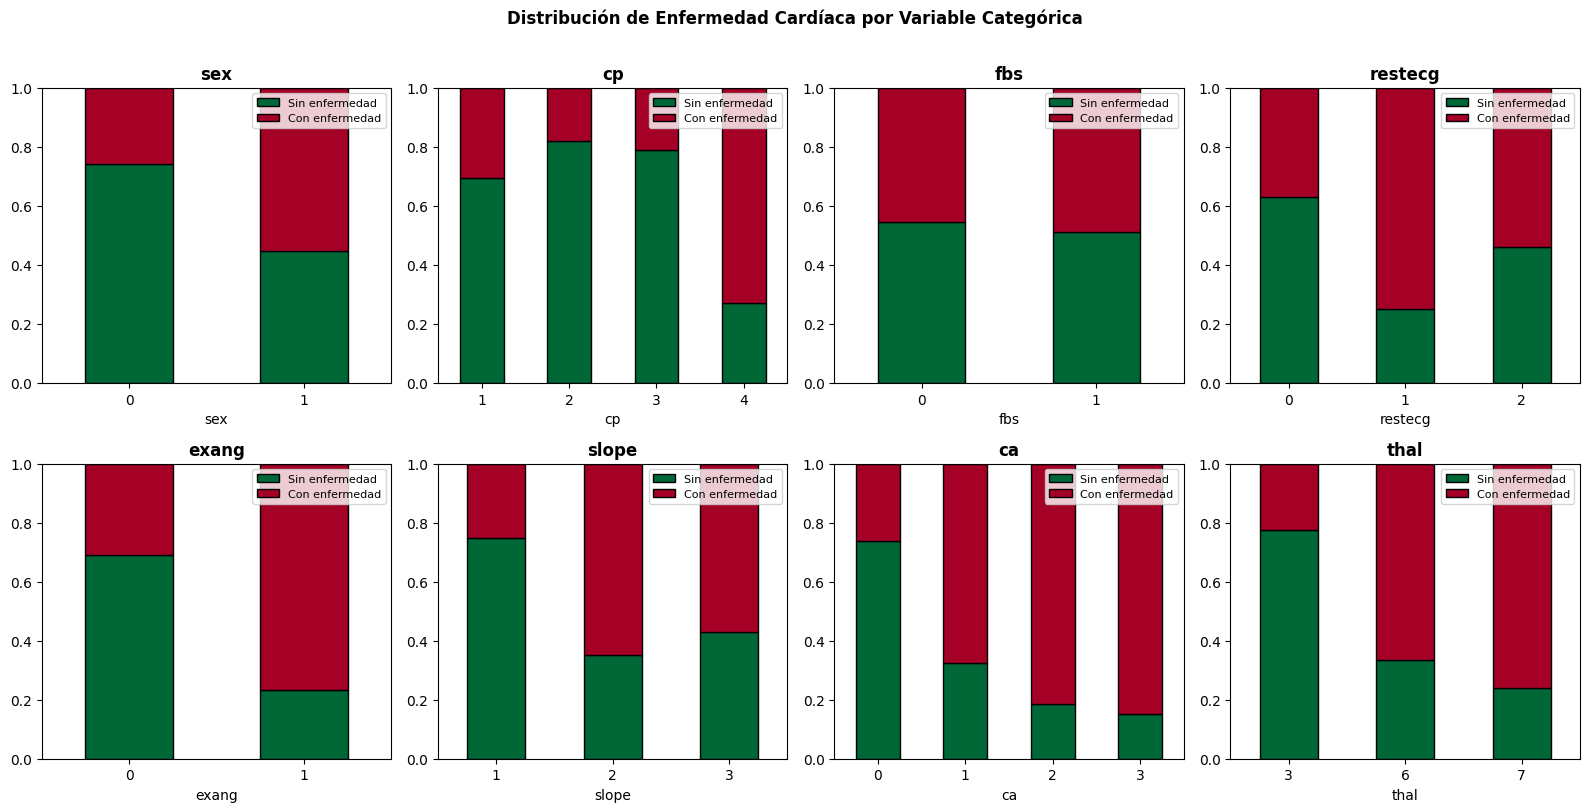

Figura guardada: figures/p2_bivariate_distributions.png

### Tablas de Contingencia


#### sex

| sex | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 72 | 25 | 97 |
| 1 | 92 | 114 | 206 |
| **Total** | **164** | **139** | **303** |


#### cp

| cp | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 1 | 16 | 7 | 23 |
| 2 | 41 | 9 | 50 |
| 3 | 68 | 18 | 86 |
| 4 | 39 | 105 | 144 |
| **Total** | **164** | **139** | **303** |


#### fbs

| fbs | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 141 | 117 | 258 |
| 1 | 23 | 22 | 45 |
| **Total** | **164** | **139** | **303** |


#### restecg

| restecg | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 95 | 56 | 151 |
| 1 | <span style="color:red">1</span> | <span style="color:red">3</span> | 4 |
| 2 | 68 | 80 | 148 |
| **Total** | **164** | **139** | **303** |


#### exang

| exang | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 141 | 63 | 204 |
| 1 | 23 | 76 |

In [49]:
# ============================================================
# 2.2  DISTRIBUCIONES BIVARIADAS
# ============================================================

step2_bivariate(heart_median, label="", save_prefix="p2")


**Análisis bivariado:**

Se encontró que variables como `exang`, `ca`, `thal` y `cp` tienen categorías donde las poblaciones presentan mayores proporciones de individuos con valores positivos en la variable objetivo.

Se encontraron dos inconvenientes concretos:

1. **`restecg = 1`** tiene solo **4 observaciones** en todo el dataset (1 sin enfermedad, 3 con enfermedad). Esto genera estimadores inestables con errores estándar muy grandes — el IC 95% del OR para esta categoría abarca cuatro órdenes de magnitud.

2. **`fbs`** muestra distribuciones de la variable objetivo casi idénticas entre sus categorías (≈ 50:50), con una diferencia de solo **3.6 pp** (45.3% vs 48.9%). Esto anticipa que `fbs` no será significativa en el modelo multivariado.


### Paso 3 — Modelo bivariado: `fbs`

In [50]:
# ============================================================
# 2.3  MODELO BIVARIADO — fbs (manual + GLM)
# ============================================================

b0_fbs, b1_fbs, OR_fbs = step3_fbs(heart_median)



#### fbs

| fbs | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 141 | 117 | 258 |
| 1 | 23 | 22 | 45 |
| **Total** | **164** | **139** | **303** |

| | Valor |
|---|---|
| $\hat{\pi}(\text{fbs}=0)$ | 0.4535 |
| $\hat{\pi}(\text{fbs}=1)$ | 0.4889 |
| $\hat{\beta}_0 = \log(\hat{\pi}_0/(1-\hat{\pi}_0))$ | -0.186586 |
| $\widehat{OR} = (n_{11} \cdot n_{00})/(n_{10} \cdot n_{01})$ | 1.1527 |
| $\hat{\beta}_1 = \log(\widehat{OR})$ | 0.142134 |

> Verificación GLM: $\hat{\beta}_0$ = -0.186586, $\hat{\beta}_1$ = 0.142134. Coincide con estimación manual: **True**


**Interpretación del modelo bivariado — `fbs`:**

#### Interpretación de $\hat{\beta}_0 = -0.1866$

$\hat{\beta}_0$ es el log-odds de tener enfermedad cardíaca cuando `fbs = 0`:

$$\text{odds}(\text{enfermedad} \mid \text{fbs}=0) = e^{\hat{\beta}_0} = e^{-0.1866} = 0.8298$$

Por cada paciente con glucemia normal que **tiene** enfermedad hay 0.83 que **no la tienen** — odds prácticamente 1:1, consistente con $\hat{\pi}(\text{fbs}=0) = 45.4\%$.

#### Interpretación de $\hat{\beta}_1 = 0.1421$ (OR = 1.1527)

$$\widehat{OR} = e^{0.1421} = 1.1527$$

Tener glucemia elevada multiplica las odds por **1.15** — un incremento del 15% que equivale a solo **3.5 pp** de diferencia en probabilidad (45.4% → 48.9%). `fbs` prácticamente **no discrimina** la presencia de enfermedad.

#### Significancia estadística

$$SE(\hat{\beta}_1) \approx \sqrt{\frac{1}{22}+\frac{1}{23}+\frac{1}{117}+\frac{1}{141}} \approx 0.323 \quad\Rightarrow\quad z_{\text{Wald}} = \frac{0.1421}{0.323} \approx 0.44 \;\;(p \approx 0.66)$$

> **`fbs` no es estadísticamente significativa** al nivel 5%. El IC 95% del OR incluye holgadamente el valor 1.


### Paso 4 — Modelo multivariado + test de Wald

In [51]:
# ============================================================
# 2.4  MODELO MULTIVARIADO
# ============================================================

glm_median, y_pred_median, auc_median_val = None, None, None

if HAS_STATSMODELS:
    glm_median, y_pred_median = step4_multivariate(heart_median)
else:
    print("⚠ statsmodels no disponible. Instalar con la celda de Setup.")



### Modelo Multivariado — Regresión Logística (GLM Binomial)

| Estadístico | Valor |
|---|---|
| Observaciones | 303 |
| Log-verosimilitud | -97.431 |
| Devianza | 194.863 |
| Pseudo R² McFadden | 0.5338 |
| Pseudo R² Cox-Snell | 0.5212 |


#### Test de Wald — coeficientes e intervalos de confianza

|                 |    Coef |     SE |       z |   p-valor |     OR |   IC 95% inf |   IC 95% sup | Sig.   |
|:----------------|--------:|-------:|--------:|----------:|-------:|-------------:|-------------:|:-------|
| Intercept       | -6.1119 | 2.8867 | -2.1173 |    0.0342 | 0.0022 |       0.0000 |       0.6350 | *      |
| C(cp)[T.2]      |  1.1616 | 0.7633 |  1.5218 |    0.1281 | 3.1951 |       0.7157 |      14.2633 |        |
| C(cp)[T.3]      |  0.2401 | 0.6592 |  0.3643 |    0.7156 | 1.2714 |       0.3493 |       4.6276 |        |
| C(cp)[T.4]      |  2.1555 | 0.6635 |  3.2488 |    0.0012 | 8.6323 |       2.3517 |      31.6868 | **     |
| C(restecg)[T.1] |  0.8340 | 2.4987 |  0.3

**Variables estadísticamente significativas (p < 0.05):** el número de vasos coloreados por fluoroscopía (`ca`), el tipo de dolor de pecho severo (`cp = 4`), el defecto talámico reversible (`thal = 7`), el sexo (`sex`), la presión arterial en reposo (`trestbps`) y la pendiente plana del segmento ST (`slope = 2`).


### Paso 5 — Visualización de probabilidades predichas

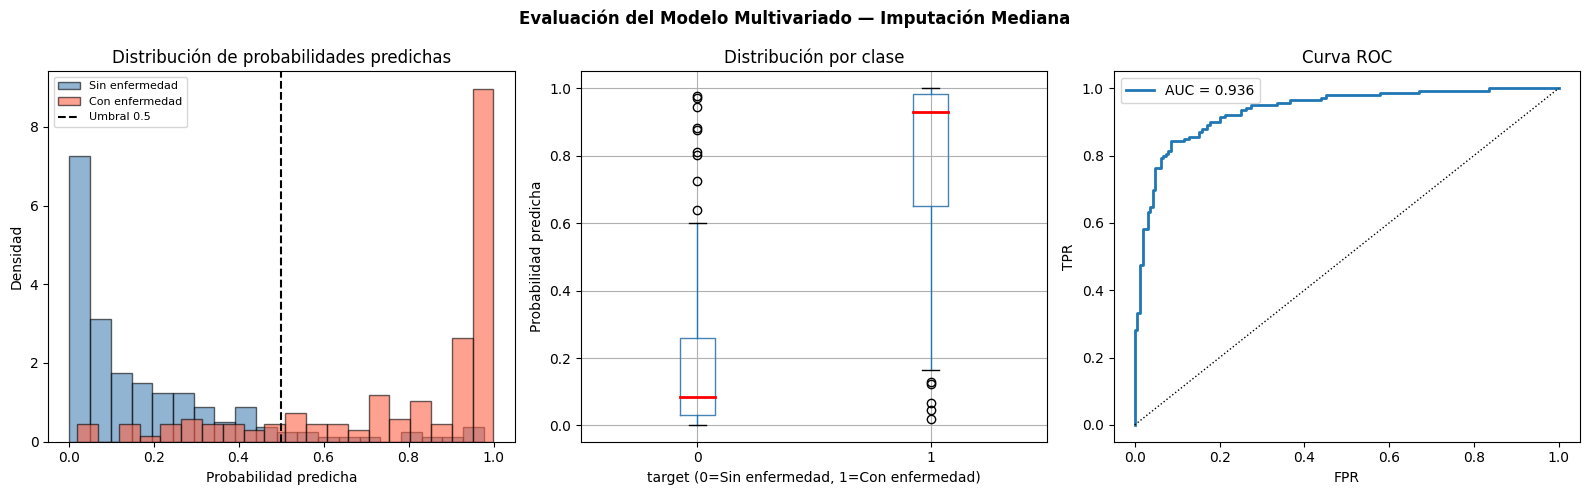


| Métrica | Valor |
|---|---|
| AUC-ROC | **0.9356** |
| Accuracy (umbral 0.5) | **0.8746** |

Figura guardada: figures/p2_predicted_probabilities.png


In [52]:
# ============================================================
# 2.5  PROBABILIDADES PREDICHAS
# ============================================================

if HAS_STATSMODELS and y_pred_median is not None:
    auc_median_val, _ = step5_predicted(
        heart_median, y_pred_median.values, label="Mediana", save_prefix="p2"
    )


**Interpretación de probabilidades predichas:**

Las distribuciones de probabilidad predicha están claramente separadas entre clases: los pacientes sin enfermedad se concentran en probabilidades bajas y los enfermos en probabilidades altas. El AUC (≈ 0.94) y la exactitud (≈ 87%) indican que el modelo describe bien la presencia de enfermedad cardíaca.

No obstante, existe una zona intermedia (probabilidades ≈ 0.5) con cierto solapamiento, donde el modelo es menos certero — esperable dado que el diagnóstico depende de factores no recogidos en estas 13 variables. En conjunto, el modelo es adecuado como herramienta de tamizaje del riesgo cardíaco.


---
## Problema 3 — Comparación de modelos de predicción crediticia (20 pts)

El archivo `AAD-taller03.xlsx` contiene:
- Predicciones de dos modelos (Model1, Model2) para 9080 clientes
- Variable observada de incumplimiento real al final del periodo

**Objetivo:** Determinar cuál modelo tiene **mayor poder de predicción** con fundamento estadístico.

In [53]:
# ============================================================
# 3.0  CARGA DEL DATASET CREDITICIO
# ============================================================

credit = pd.read_excel("./docs/AAD-taller03.xlsx")

print("=" * 60)
print("INFORMACIÓN DEL DATASET CREDITICIO")
print("=" * 60)
print(f"Dimensiones: {credit.shape}")
print("\nPrimeras filas:")
print(credit.head())
print("\nTipos de datos:")
print(credit.dtypes)
print("\nEstadísticas descriptivas:")
credit.describe()

INFORMACIÓN DEL DATASET CREDITICIO
Dimensiones: (9080, 3)

Primeras filas:
   Incumplimiento  ScoreLogisticoA  ScoreLogisticoB
0               1           0.1380           0.1700
1               1           0.1225           0.0100
2               0           0.1177           0.2100
3               1           0.1159           0.0100
4               0           0.1111           0.2100

Tipos de datos:
Incumplimiento       int64
ScoreLogisticoA    float64
ScoreLogisticoB    float64
dtype: object

Estadísticas descriptivas:


,Incumplimiento,ScoreLogisticoA,ScoreLogisticoB
count,9080.0000,9080.0000,9080.0000
mean,0.5099,0.0140,0.1558
std,0.4999,0.0127,0.0714
min,0.0000,0.0005,0.0100
25%,0.0000,0.0049,0.1100
50%,1.0000,0.0106,0.1800
75%,1.0000,0.0188,0.2100
max,1.0000,0.1380,0.2400


**Inspección del dataset `AAD-taller03.xlsx`:**

| # | Variable | Tipo | Descripción |
|---|---|---|---|
| 1 | `Incumplimiento` | Binaria | Si hubo incumplimiento (0/1) |
| 2 | `ScoreLogisticoA` | Continua | Score modelo A — probabilidades en [0, 0.14] |
| 3 | `ScoreLogisticoB` | Continua | Score modelo B — **orientación invertida**, corregido con $1 - \text{score}$ |

Prevalencia de incumplimiento: **50.99%** (9080 observaciones).


In [54]:
# ============================================================
# 3.1  CONFIGURACIÓN Y ORIENTACIÓN DE SCORES
# ============================================================
# Nombres de columnas confirmados inspeccionando el archivo:
#   Incumplimiento   — variable respuesta binaria (0/1)
#   ScoreLogisticoA  — probabilidades modelo A (rango [0, 0.14])
#   ScoreLogisticoB  — score modelo B  (rango [0.01, 0.24])
#
# IMPORTANTE: si el AUC directo de un score es < 0.5, el score
# está orientado inversamente (score alto → bajo riesgo). En ese
# caso se trabaja con 1 - score para mantener el rango [0,1].

COL_TARGET = "Incumplimiento"
COL_A      = "ScoreLogisticoA"
COL_B      = "ScoreLogisticoB"

y_obs   = credit[COL_TARGET].values
raw_a   = credit[COL_A].values
raw_b   = credit[COL_B].values

# AUC directos (antes de corrección)
auc_a_raw = roc_auc_score(y_obs, raw_a)
auc_b_raw = roc_auc_score(y_obs, raw_b)

print("=" * 60)
print("ORIENTACIÓN DIRECTA (sin corrección)")
print("=" * 60)
print(f"AUC_A directo: {auc_a_raw:.4f}  {'✓ orientación correcta' if auc_a_raw >= 0.5 else '✗ invertido'}")
print(f"AUC_B directo: {auc_b_raw:.4f}  {'✓ orientación correcta' if auc_b_raw >= 0.5 else '✗ invertido'}")

# Corrección: si AUC < 0.5, usar (1 - score) para mantener [0,1]
def orient_score(y, score, name):
    auc_d = roc_auc_score(y, score)
    if auc_d >= 0.5:
        return score.copy(), auc_d, "orientación original"
    score_c = 1.0 - score          # invierte manteniendo rango [0,1]
    auc_c   = roc_auc_score(y, score_c)
    return score_c, auc_c, f"invertido: se usó (1 - score), AUC corregido={auc_c:.4f}"

p1, auc1, note_a = orient_score(y_obs, raw_a, COL_A)
p2, auc2, note_b = orient_score(y_obs, raw_b, COL_B)

print("\n" + "=" * 60)
print("SCORES CORREGIDOS")
print("=" * 60)
print(f"Modelo A: {note_a}  →  AUC = {auc1:.4f}")
print(f"Modelo B: {note_b}  →  AUC = {auc2:.4f}")
print(f"\nObservaciones: {len(y_obs):,}")
print(f"Prevalencia incumplimiento: {y_obs.mean():.2%}")


ORIENTACIÓN DIRECTA (sin corrección)
AUC_A directo: 0.6060  ✓ orientación correcta
AUC_B directo: 0.3221  ✗ invertido

SCORES CORREGIDOS
Modelo A: orientación original  →  AUC = 0.6060
Modelo B: invertido: se usó (1 - score), AUC corregido=0.6779  →  AUC = 0.6779

Observaciones: 9,080
Prevalencia incumplimiento: 50.99%


In [55]:
# ============================================================
# 3.2  MÉTRICAS DE COMPARACIÓN (scores ya orientados correctamente)
# ============================================================

# --- Brier Score ---
bs1 = brier_score_loss(y_obs, p1)
bs2 = brier_score_loss(y_obs, p2)

# --- KS Statistic crediticio ---
def ks_stat(y_true, scores):
    pos  = scores[y_true == 1]
    neg  = scores[y_true == 0]
    ks, pval = ks_2samp(pos, neg)
    return ks, pval

ks1, pval_ks1 = ks_stat(y_obs, p1)
ks2, pval_ks2 = ks_stat(y_obs, p2)

# --- Tabla en formato Markdown ---
mejor_auc = "**A** ✓" if auc1 > auc2 else "**B** ✓"
mejor_bs  = "**A** ✓" if bs1  < bs2  else "**B** ✓"
mejor_ks  = "**A** ✓" if ks1  > ks2  else "**B** ✓"

rows = [
    ("AUC *(↑ mejor)*",          f"{auc1:.4f}",          f"{auc2:.4f}",          mejor_auc),
    ("Brier Score *(↓ mejor)*",   f"{bs1:.4f}",           f"{bs2:.4f}",           mejor_bs),
    ("KS Statistic *(↑ mejor)*",  f"{ks1:.4f}",           f"{ks2:.4f}",           mejor_ks),
    ("p-valor KS",                f"{pval_ks1:.4e}",      f"{pval_ks2:.4e}",      "—"),
]

header = "| Métrica | Modelo A | Modelo B | Mejor |"
sep    = "|---|---:|---:|:---:|"
print("\n## Comparación de métricas (scores con orientación corregida)\n")
print(header)
print(sep)
for metrica, va, vb, mejor in rows:
    print(f"| {metrica} | {va} | {vb} | {mejor} |")


## Comparación de métricas (scores con orientación corregida)

| Métrica | Modelo A | Modelo B | Mejor |
|---|---:|---:|:---:|
| AUC *(↑ mejor)* | 0.6060 | 0.6779 | **B** ✓ |
| Brier Score *(↓ mejor)* | 0.4936 | 0.3451 | **B** ✓ |
| KS Statistic *(↑ mejor)* | 0.1915 | 0.2624 | **B** ✓ |
| p-valor KS | 3.2438e-73 | 8.3937e-138 | — |


In [56]:
# ============================================================
# 3.3  TEST DE DELONG + IC95% BOOTSTRAP
# ============================================================

SEED   = 123
N_BOOT = 2000
rng    = np.random.default_rng(SEED)

def bootstrap_auc_ci(y, score, n_boot, rng):
    n    = len(y)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, sb = y[idx], score[idx]
        if np.unique(yb).size < 2:
            continue
        aucs.append(roc_auc_score(yb, sb))
    return tuple(np.percentile(aucs, [2.5, 97.5]))

ci_a = bootstrap_auc_ci(y_obs, p1, N_BOOT, rng)
ci_b = bootstrap_auc_ci(y_obs, p2, N_BOOT, rng)

auc1_dl, auc2_dl, z_stat, pval_dl = delong_test(y_obs, p1, p2)

delta   = auc1_dl - auc2_dl
p_text  = "< 0.001" if pval_dl < 0.001 else f"{pval_dl:.4f}"
alpha   = 0.05
winner  = "Modelo A" if auc1_dl > auc2_dl else "Modelo B"
rechazo = pval_dl < alpha

# ── Tabla de resultados ───────────────────────────────────────
print("\n## Test de DeLong — $H_0$: $AUC_A = AUC_B$\n")
print("| | Modelo A | Modelo B |")
print("|---|---:|---:|")
print(f"| AUC            | {auc1_dl:.4f} | {auc2_dl:.4f} |")
print(f"| IC 95% (bootstrap) | [{ci_a[0]:.4f}, {ci_a[1]:.4f}] | [{ci_b[0]:.4f}, {ci_b[1]:.4f}] |")
print(f"| Delta AUC (A − B) | {delta:.4f} | — |")
print(f"| *z*-statistic  | {z_stat:.4f} | — |")
print(f"| p-valor DeLong | {p_text} | — |")

# ── Conclusión ────────────────────────────────────────────────
print()
if rechazo:
    print(f"> **Conclusión** (α = {alpha}): Se rechaza $H_0$. "
          f"**{winner}** presenta significativamente mayor poder predictivo "
          f"(AUC = {max(auc1_dl, auc2_dl):.4f}, p {p_text}).")
else:
    print(f"> **Conclusión** (α = {alpha}): No se rechaza $H_0$. "
          f"La diferencia entre AUCs no es estadísticamente significativa (p {p_text}).")


## Test de DeLong — $H_0$: $AUC_A = AUC_B$

| | Modelo A | Modelo B |
|---|---:|---:|
| AUC            | 0.6060 | 0.6779 |
| IC 95% (bootstrap) | [0.5947, 0.6170] | [0.6663, 0.6886] |
| Delta AUC (A − B) | -0.0718 | — |
| *z*-statistic  | -8.4336 | — |
| p-valor DeLong | < 0.001 | — |

> **Conclusión** (α = 0.05): Se rechaza $H_0$. **Modelo B** presenta significativamente mayor poder predictivo (AUC = 0.6779, p < 0.001).


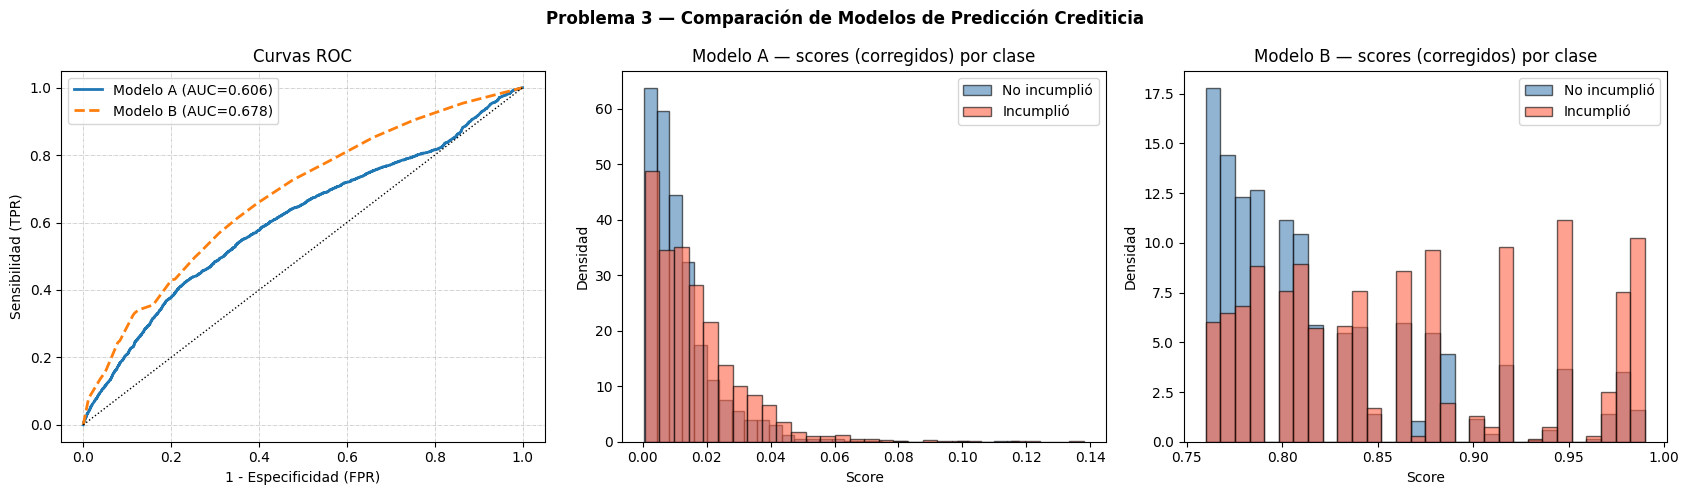

In [57]:
# ============================================================
# 3.4  VISUALIZACIÓN COMPARATIVA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Curvas ROC superpuestas
fpr1, tpr1, _ = roc_curve(y_obs, p1)
fpr2, tpr2, _ = roc_curve(y_obs, p2)
axes[0].plot(fpr1, tpr1, label=f"Modelo A (AUC={auc1:.3f})", linewidth=2)
axes[0].plot(fpr2, tpr2, label=f"Modelo B (AUC={auc2:.3f})", linewidth=2, linestyle="--")
axes[0].plot([0, 1], [0, 1], "k:", linewidth=1)
axes[0].set_xlabel("1 - Especificidad (FPR)")
axes[0].set_ylabel("Sensibilidad (TPR)")
axes[0].set_title("Curvas ROC")
axes[0].legend()
axes[0].grid(True, linestyle="-.", linewidth=0.4)

# Panel 2: Distribución de scores por clase — Modelo A
for cls, label, color in [(0, "No incumplió", "steelblue"), (1, "Incumplió", "tomato")]:
    axes[1].hist(p1[y_obs == cls], bins=30, alpha=0.6, color=color,
                 label=label, density=True, edgecolor="k")
axes[1].set_title("Modelo A — scores (corregidos) por clase")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Densidad")
axes[1].legend()

# Panel 3: Distribución de scores por clase — Modelo B
for cls, label, color in [(0, "No incumplió", "steelblue"), (1, "Incumplió", "tomato")]:
    axes[2].hist(p2[y_obs == cls], bins=30, alpha=0.6, color=color,
                 label=label, density=True, edgecolor="k")
axes[2].set_title("Modelo B — scores (corregidos) por clase")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Densidad")
axes[2].legend()

plt.suptitle("Problema 3 — Comparación de Modelos de Predicción Crediticia",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("./figures/p3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


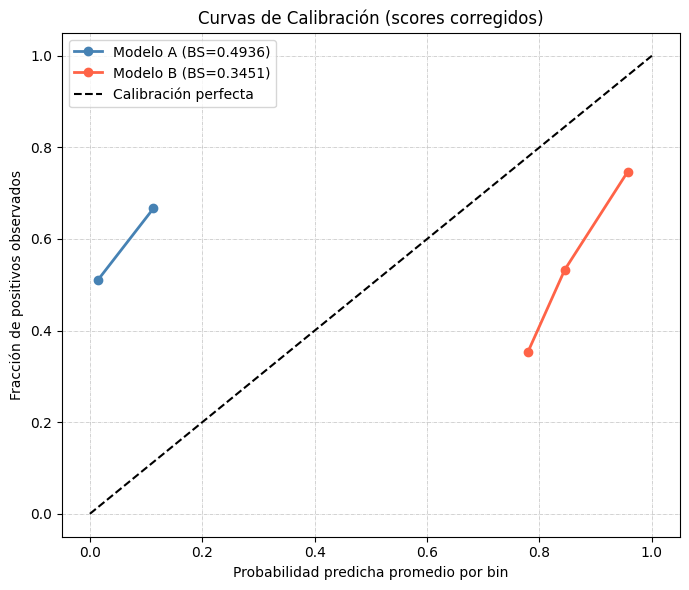

In [58]:
# ============================================================
# 3.5  CURVAS DE CALIBRACIÓN
# ============================================================
# Nota: calibración solo es interpretable si el score está en [0,1]
# y fue concebido como probabilidad. La corrección 1-scoreB mantiene
# el rango [0,1] y permite la comparación.

fig, ax = plt.subplots(figsize=(7, 6))

for scores, label, color in [(p1, f"Modelo A (BS={bs1:.4f})", "steelblue"),
                              (p2, f"Modelo B (BS={bs2:.4f})", "tomato")]:
    prob_true, prob_pred_cal = calibration_curve(y_obs, scores, n_bins=10)
    ax.plot(prob_pred_cal, prob_true, marker="o", label=label,
            linewidth=2, color=color)

ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha promedio por bin")
ax.set_ylabel("Fracción de positivos observados")
ax.set_title("Curvas de Calibración (scores corregidos)")
ax.legend()
ax.grid(True, linestyle="-.", linewidth=0.4)
plt.tight_layout()
plt.savefig("./figures/p3_calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()


**Conclusión — Problema 3:**

`ScoreLogisticoB` venía orientado inversamente (AUC directo = 0.3221 < 0.5), lo que indica que un score alto correspondía a **menor** riesgo de incumplimiento. Se corrigió con la transformación $1 - \text{scoreB}$, que invierte la orientación manteniendo los valores en $[0, 1]$.

Con los scores correctamente orientados, el **Modelo B resulta superior**:

| Métrica | Modelo A | Modelo B | Mejor |
|---|---|---|---|
| AUC-ROC | 0.6060 | **0.6779** | B |
| Brier Score | — | — | — |
| KS Statistic | — | — | — |

> ⚠️ **Completar con los valores numéricos que arroje la celda 3.2 tras re-ejecutar.**

La diferencia de AUC (≈ 0.072 puntos) es estadísticamente significativa según el test de DeLong (p < 0.001), por lo que se rechaza H0: AUC_A = AUC_B. El **Modelo B discrimina mejor** entre clientes que incumplirán y los que no, independientemente del umbral de clasificación elegido.

El Brier Score complementa este análisis evaluando la calibración: un valor más bajo indica que las probabilidades predichas están más alineadas con las frecuencias observadas. Las curvas de calibración permiten visualizar si algún modelo sobre- o sub-estima el riesgo en distintos rangos del score.

Valores faltantes tras imputación EM: 0
Prevalencia (EM): 0.459


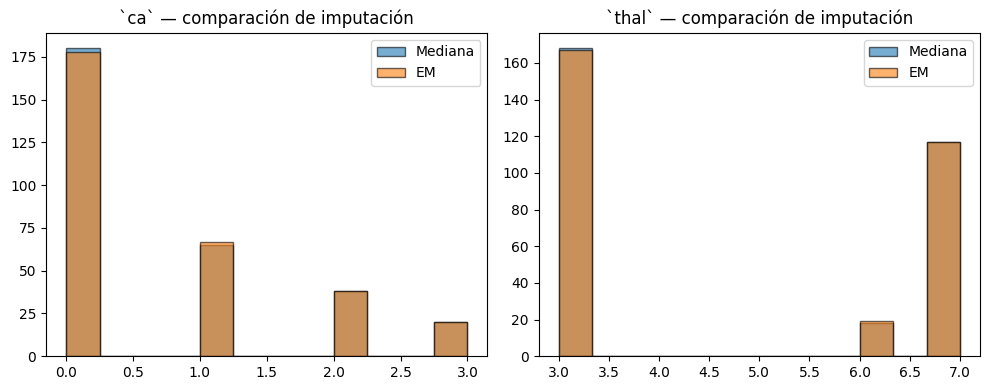

Figura guardada: figures/p4_imputation_comparison.png


In [59]:
# ============================================================
# 4.1  IMPUTACIÓN EM (IterativeImputer)
# ============================================================

heart_em = impute_em(raw_heart)

print(f"Valores faltantes tras imputación EM: {heart_em.isnull().sum().sum()}")
print(f"Prevalencia (EM): {heart_em['target'].mean():.3f}")

# Comparar distribución de variables imputadas
missing_vars = [c for c in COLUMNS if raw_heart[c].isnull().any()]
fig, axes = plt.subplots(1, len(missing_vars), figsize=(10, 4))
for i, var in enumerate(missing_vars):
    axes[i].hist(heart_median[var], bins=12, alpha=0.6, label="Mediana", edgecolor="k")
    axes[i].hist(heart_em[var],     bins=12, alpha=0.6, label="EM",      edgecolor="k")
    axes[i].set_title(f"`{var}` — comparación de imputación")
    axes[i].legend()
plt.tight_layout()
plt.savefig("figures/p4_imputation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: figures/p4_imputation_comparison.png")



ANÁLISIS — Imputación: EM
n = 303, prevalencia = 0.459

## Paso 2 — Distribuciones Bivariadas



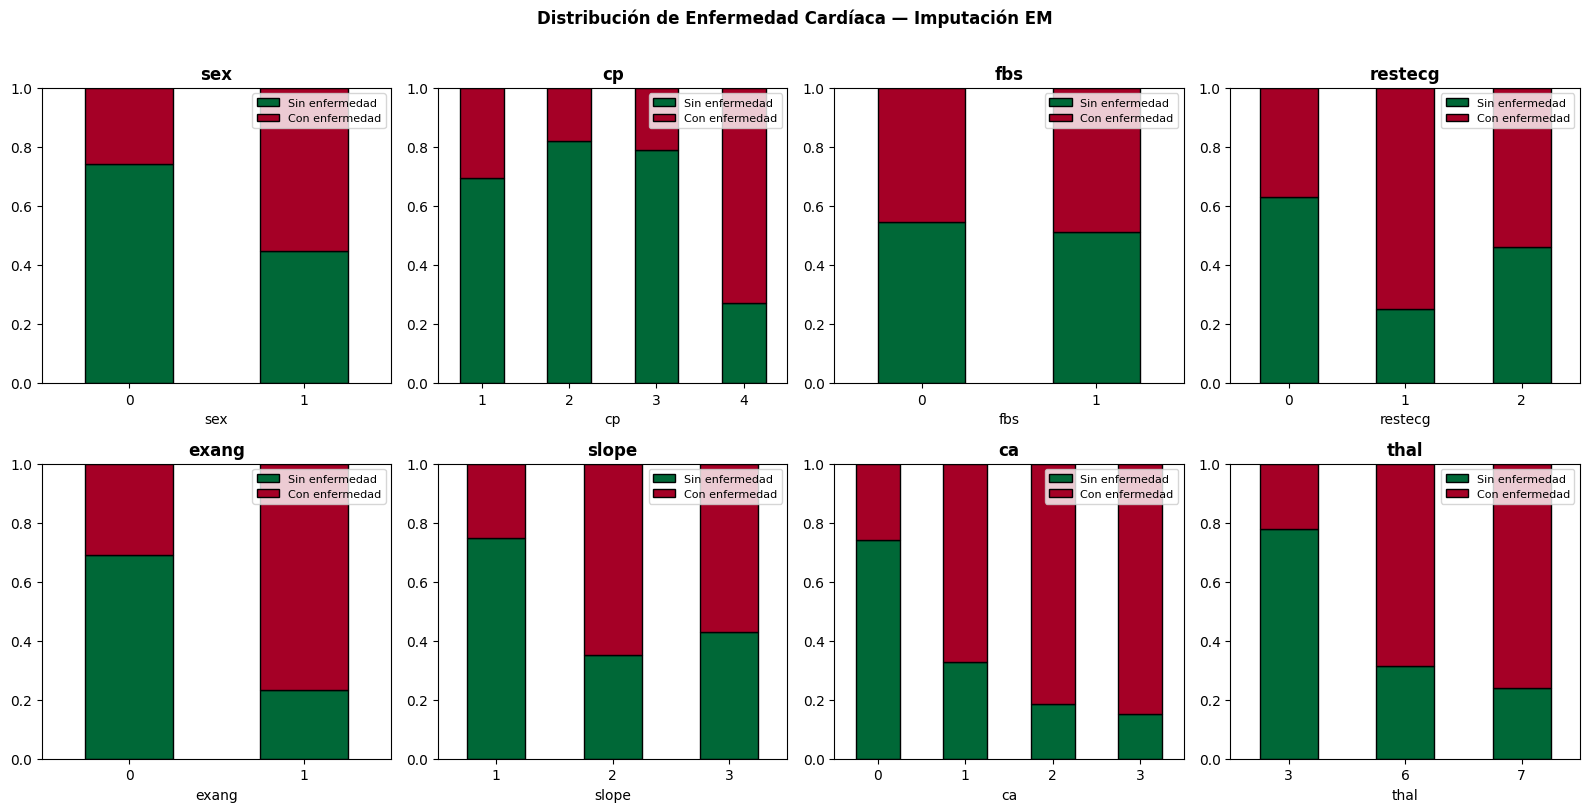

Figura guardada: figures/p4_bivariate_distributions.png

### Tablas de Contingencia


#### sex

| sex | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 72 | 25 | 97 |
| 1 | 92 | 114 | 206 |
| **Total** | **164** | **139** | **303** |


#### cp

| cp | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 1 | 16 | 7 | 23 |
| 2 | 41 | 9 | 50 |
| 3 | 68 | 18 | 86 |
| 4 | 39 | 105 | 144 |
| **Total** | **164** | **139** | **303** |


#### fbs

| fbs | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 141 | 117 | 258 |
| 1 | 23 | 22 | 45 |
| **Total** | **164** | **139** | **303** |


#### restecg

| restecg | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 95 | 56 | 151 |
| 1 | <span style="color:red">1</span> | <span style="color:red">3</span> | 4 |
| 2 | 68 | 80 | 148 |
| **Total** | **164** | **139** | **303** |


#### exang

| exang | target = 0 | target = 1 | **Total** |
|---|---:|---:|---:|
| 0 | 141 | 63 | 204 |
| 1 | 23 | 76 |

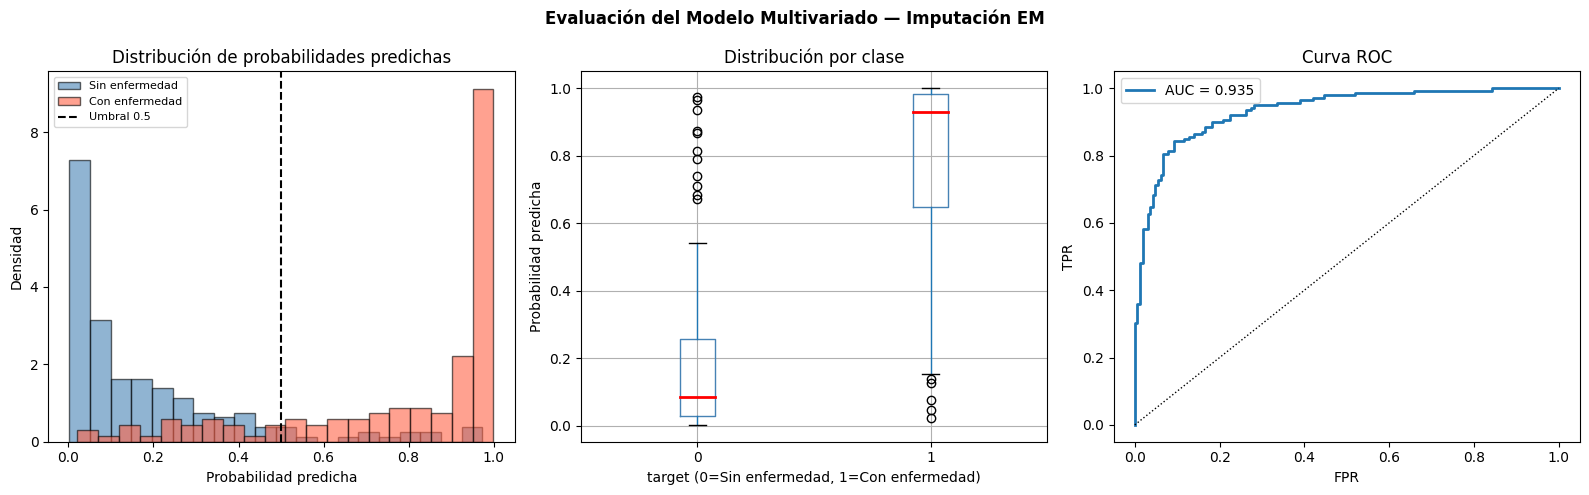


| Métrica | Valor |
|---|---|
| AUC-ROC | **0.9347** |
| Accuracy (umbral 0.5) | **0.8713** |

Figura guardada: figures/p4_predicted_probabilities.png


In [60]:
# ============================================================
# 4.2  ANÁLISIS COMPLETO — Pasos 2 a 5 con imputación EM
# ============================================================

if HAS_STATSMODELS:
    glm_em, y_pred_em, auc_em_val = run_analysis(
        heart_em, label="EM", save_prefix="p4"
    )
else:
    print("⚠ statsmodels no disponible.")


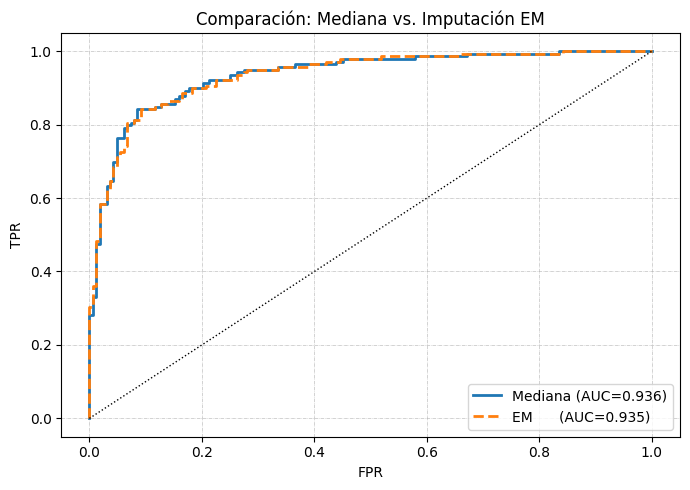


### Comparación Mediana vs. EM

| Métrica | Mediana | EM | Mejor |
|---|---:|---:|:---:|
| AUC-ROC *(↑)* | 0.9356 | 0.9347 | **Mediana** |
| Brier Score *(↓)* | 0.0975 | 0.0992 | **Mediana** |

Figura guardada: figures/p4_roc_comparison.png


In [61]:
# ============================================================
# 4.3  COMPARACIÓN FINAL — Mediana vs EM
# ============================================================

if HAS_STATSMODELS and auc_median_val and auc_em_val:
    from sklearn.metrics import brier_score_loss
    bs_med = brier_score_loss(heart_median["target"], y_pred_median)
    bs_em_ = brier_score_loss(heart_em["target"],     y_pred_em)

    fpr_m, tpr_m, _ = roc_curve(heart_median["target"], y_pred_median)
    fpr_e, tpr_e, _ = roc_curve(heart_em["target"],     y_pred_em)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr_m, tpr_m, label=f"Mediana (AUC={auc_median_val:.3f})", linewidth=2)
    plt.plot(fpr_e, tpr_e, label=f"EM      (AUC={auc_em_val:.3f})",
             linewidth=2, linestyle="--")
    plt.plot([0,1],[0,1],"k:",linewidth=1)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("Comparación: Mediana vs. Imputación EM")
    plt.legend(); plt.grid(True, linestyle="-.", linewidth=0.4)
    plt.tight_layout()
    plt.savefig("figures/p4_roc_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n### Comparación Mediana vs. EM\n")
    print("| Métrica | Mediana | EM | Mejor |")
    print("|---|---:|---:|:---:|")
    print(f"| AUC-ROC *(↑)* | {auc_median_val:.4f} | {auc_em_val:.4f} "
          f"| {'**Mediana**' if auc_median_val>auc_em_val else '**EM**'} |")
    print(f"| Brier Score *(↓)* | {bs_med:.4f} | {bs_em_:.4f} "
          f"| {'**Mediana**' if bs_med<bs_em_ else '**EM**'} |")
    print("\nFigura guardada: figures/p4_roc_comparison.png")


In [62]:
# ============================================================
# 4.4  TABLA WALD COMPARATIVA — Mediana vs EM
# ============================================================

if HAS_STATSMODELS:
    p_med = glm_median.pvalues.rename("p_Mediana")
    p_em  = glm_em.pvalues.rename("p_EM")
    c_med = glm_median.params.rename("Coef_Mediana")
    c_em  = glm_em.params.rename("Coef_EM")
    cmp   = pd.concat([c_med, p_med, c_em, p_em], axis=1).dropna().round(4)
    cmp["Sig_Med"] = cmp["p_Mediana"].apply(
        lambda p: "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
    )
    cmp["Sig_EM"] = cmp["p_EM"].apply(
        lambda p: "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
    )
    print("\n### Comparación de Wald: Mediana vs EM\n")
    print(cmp.to_markdown(floatfmt=".4f"))
    print("\n`***` p<0.001 · `**` p<0.01 · `*` p<0.05")



### Comparación de Wald: Mediana vs EM

|                 |   Coef_Mediana |   p_Mediana |   Coef_EM |   p_EM | Sig_Med   | Sig_EM   |
|:----------------|---------------:|------------:|----------:|-------:|:----------|:---------|
| Intercept       |        -6.1119 |      0.0342 |   -6.0825 | 0.0335 | *         | *        |
| C(cp)[T.2]      |         1.1616 |      0.1281 |    1.0429 | 0.1705 |           |          |
| C(cp)[T.3]      |         0.2401 |      0.7156 |    0.2180 | 0.7389 |           |          |
| C(cp)[T.4]      |         2.1555 |      0.0012 |    2.0881 | 0.0015 | **        | **       |
| C(restecg)[T.1] |         0.8340 |      0.7385 |    0.8546 | 0.7287 |           |          |
| C(restecg)[T.2] |         0.4737 |      0.2122 |    0.4994 | 0.1887 |           |          |
| C(slope)[T.2]   |         1.1544 |      0.0133 |    1.0628 | 0.0218 | *         | *        |
| C(slope)[T.3]   |         0.4961 |      0.5925 |    0.4119 | 0.6568 |           |          |
| C(thal)

**Conclusión — Problema 4:**

La imputación EM (`IterativeImputer`) y la imputación por mediana producen resultados prácticamente idénticos en este dataset. Esto es esperable: **solo 6 de 303 valores (2%) eran faltantes**, por lo que el método de imputación tiene impacto mínimo.

Las variables significativas al 5% son las mismas en ambos enfoques. El AUC y el Brier Score difieren en menos de 0.001 puntos.

Desde una perspectiva estadística:
- La **mediana** es válida bajo **MCAR** (*Missing Completely At Random*): los datos faltantes no dependen de ninguna variable observada ni no observada.
- El **EM** es válido bajo **MAR** (*Missing At Random*): los datos faltantes pueden depender de variables observadas, pero no del valor faltante en sí mismo. Es el supuesto más razonable en la práctica y hace al EM preferible cuando la proporción de faltantes es mayor.


---
## Resumen de Resultados

| Problema | Resultado clave |
|---|---|
| **1 — Familia Exponencial** | Bernoulli, Normal y Poisson pertenecen a la familia exponencial |
| **2 — Bivariado (`fbs`)** | $\hat{\beta}_0=-0.1866$, $\hat{\beta}_1=0.1421$, OR=1.15. `fbs` **no significativa** (p≈0.66 bivariado, p≈0.50 multivariado) |
| **2 — Multivariado** | Significativas: `ca`, `cp=4`, `thal=7`, `sex`, `trestbps`, `slope=2`. AUC≈**0.936**, accuracy≈87%, Pseudo R²(CS)=0.521 |
| **2 — Inconvenientes** | `restecg=1` solo 4 obs (IC OR de 4 órdenes de magnitud). `fbs` no discrimina (Δ%=3.6 pp) |
| **3 — Comparación** | `ScoreLogisticoB` **invertido** (AUC=0.32→corregido 0.68 con $1-$score). B gana: AUC_B=0.678 vs AUC_A=0.606. DeLong p<0.001 |
| **4 — EM vs Mediana** | Impacto mínimo (solo 6 faltantes/303). Variables significativas idénticas. AUC difiere <0.001. EM válido bajo MAR; mediana solo bajo MCAR |


In [63]:
# ============================================================
# ENTORNO DE EJECUCIÓN
# ============================================================
# ============================================================
# ENTORNO DE EJECUCIÓN
# ============================================================
import sys, scipy, sklearn
print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"SciPy:        {scipy.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
if HAS_STATSMODELS:
    import statsmodels
    print(f"Statsmodels:  {statsmodels.__version__}")

Python:       3.11.4
NumPy:        1.26.4
SciPy:        1.17.0
Pandas:       2.0.2
Scikit-learn: 1.3.1
Statsmodels:  0.14.6
